# Aktienmarkt-Analyse & Modellvergleich
## Vorhersage des Google-Aktienkurses (GOOGL)

Diese Präsentation zeigt den vollständigen Machine-Learning-Workflow:
- Datenbeschaffung
- Datenbereinigung & Feature Engineering
- Modelltraining (Lineare Regression, Random Forest, Gradient Boosting)
- Modellevaluation

In [ ]:
import warnings
warnings.filterwarnings('ignore')

## 1. Datenbeschaffung
Wir laden die historischen Aktiendaten für den Ticker **GOOGL** direkt über die Yahoo Finance API.

In [1]:
import yfinance as yf
import pandas as pd

ticker_symbol = "GOOGL"
print(f"Lade Daten für {ticker_symbol}...")

df = yf.download(ticker_symbol, period="3y")

print(f"Daten erfolgreich geladen. Anzahl Zeilen: {len(df)}")
df.head()

Lade Daten für GOOGL...


[*********************100%***********************]  1 of 1 completed

Daten erfolgreich geladen. Anzahl Zeilen: 753


Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2023-09-26,127.358101,129.131222,126.020820,128.546787,25718700
2023-09-27,129.309540,129.666147,127.358123,127.358123,22746500
2023-09-28,131.062881,132.043555,128.566630,128.616162,22513100
2023-09-29,129.626526,132.786460,129.131239,132.023713,30859800
2023-10-02,132.905319,133.152963,129.933597,129.973228,22288000


## 2. Datenbereinigung
Im nächsten Schritt bereinigen wir die Rohdaten.
Wir entfernen überflüssige Spalten, behandeln fehlende Werte und formatieren den DataFrame korrekt.

In [2]:
# MultiIndex entfernen (falls durch yfinance generiert)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

# Wir beschränken uns auf die wichtigsten Spalten und löschen NaNs
df_clean = df[['Close', 'Volume']].copy().dropna()

print(f"Anzahl der Datensätze nach Bereinigung: {len(df_clean)}")

Anzahl der Datensätze nach Bereinigung: 753


## 3. Feature Engineering
Um unseren Modellen mehr Aussagekraft zu geben, berechnen wir zusätzliche Features:
- **Lags:** Verzögerte Renditen (Momentum-Effekt)
- **SMA:** Simple Moving Averages für 10 und 50 Tage
- **Volatilität:** Standardabweichung über 20 Tage
- **RSI:** Relative Strength Index (14 Tage)

In [3]:
import pandas_ta as ta

df_features = df_clean.copy()

# Basis-Rendite von heute
df_features['Return_Today'] = df_features['Close'].diff()

# Lags (Verzögerungen)
df_features['Return_Lag_1'] = df_features['Return_Today'].shift(1)
df_features['Return_Lag_2'] = df_features['Return_Today'].shift(2)
df_features['Return_Lag_3'] = df_features['Return_Today'].shift(3)

# Gleitende Durchschnitte
df_features['SMA_10'] = df_features['Close'].rolling(window=10).mean()
df_features['SMA_50'] = df_features['Close'].rolling(window=50).mean()

# Volatilität und RSI
df_features['Volatility_20'] = df_features['Return_Today'].rolling(window=20).std()
df_features['RSI_14'] = df_features.ta.rsi(close='Close', length=14)

# Unser Target (Preisveränderung von heute auf morgen)
df_features['Target'] = df_features['Close'].diff().shift(-1)

# Start-Zeilen löschen (aufgrund von 50-Tage SMA)
df_features = df_features.dropna()
df_features[['Close', 'Target', 'SMA_50', 'RSI_14']].tail()

Price,Close,Target,SMA_50,RSI_14
Date,,,,
2026-09-18,349.540009,5.429993,345.399058,55.088551
2026-09-21,354.970001,-3.809998,345.359446,58.896953
2026-09-22,351.160004,-13.330017,345.336975,55.350322
2026-09-23,337.829987,4.529999,344.907993,45.114360
2026-09-24,342.359985,1.560028,344.341558,48.593550


## 4. Trainingsvorbereitung & Split
Wir definieren unsere Features und teilen die Daten in ein **Trainingsset (80%)** und ein **Testset (20%)** auf.
Dadurch evaluieren wir das Modell auf völlig neuen, ungesehenen Daten.

In [4]:
features = [
    'Close', 'Volume', 'Return_Today', 
    'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 
    'SMA_10', 'SMA_50', 
    'Volatility_20', 'RSI_14'
]

split_index = int(len(df_features) * 0.8)
train_data = df_features.iloc[:split_index]
test_data = df_features.iloc[split_index:]

X_train, y_train = train_data[features], train_data['Target']
X_test, y_test = test_data[features], test_data['Target']

print(f"Trainingsdaten: {X_train.shape[0]} Zeilen")
print(f"Testdaten: {X_test.shape[0]} Zeilen")

Trainingsdaten: 562 Zeilen
Testdaten: 141 Zeilen


## 5. Modelltraining
Wir trainieren drei unterschiedliche Machine-Learning-Modelle auf denselben Trainingsdaten, um deren Performance zu vergleichen:
1. **Lineare Regression** (Baseline)
2. **Random Forest Regressor**
3. **Gradient Boosting Regressor**

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# 1. Lineare Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 2. Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

print("Alle drei Modelle wurden erfolgreich trainiert!")

Alle drei Modelle wurden erfolgreich trainiert!


## 6. Modellevaluation & Vergleich
Wir werten die Modelle anhand der Predictions auf dem ungesehenen Testset aus.
Besonders achten wir auf den mittleren absoluten Fehler (**MAE**), die Fehlerquadrate (**RMSE**) und die Trefferquote.

In [6]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def print_evaluation(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    hit_rate = (np.sign(y_true) == np.sign(y_pred)).mean() * 100
    
    print(f"{name}")
    print(f"MAE: {mae:.2f} $ | RMSE: {rmse:.2f} $ | R²: {r2:.2f} | Trefferquote: {hit_rate:.2f} %")
    print("=" * 75)

lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)
gb_preds = gb_model.predict(X_test)

print_evaluation("Lineare Regression", y_test, lr_preds)
print_evaluation("Random Forest", y_test, rf_preds)
print_evaluation("Gradient Boosting", y_test, gb_preds)

Lineare Regression
MAE: 5.45 $ | RMSE: 7.60 $ | R²: 0.00 | Trefferquote: 48.23 %
Random Forest
MAE: 5.74 $ | RMSE: 7.88 $ | R²: -0.08 | Trefferquote: 50.35 %
Gradient Boosting
MAE: 6.44 $ | RMSE: 8.69 $ | R²: -0.31 | Trefferquote: 53.19 %


### Grafische Auswertung: Lineare Regression
Visueller Vergleich der Baseline-Vorhersagen (rot gestrichelt) mit den tatsächlichen Werten (blau).

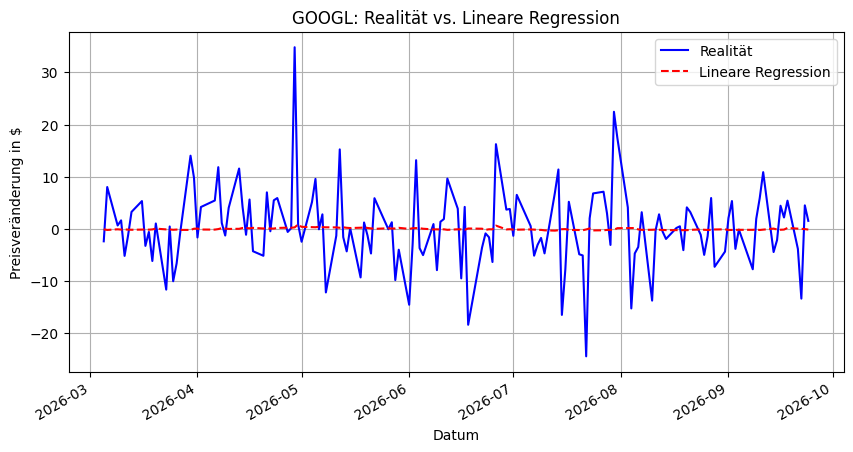

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(test_data.index, y_test.values, color='blue', label='Realität')
plt.plot(test_data.index, lr_preds, color='red', linestyle='--', label='Lineare Regression')
plt.xlabel('Datum')
plt.ylabel('Preisveränderung in $')
plt.title('GOOGL: Realität vs. Lineare Regression')
plt.legend(loc='upper right')
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()

### Grafische Auswertung: Random Forest
Hier sehen wir die Vorhersagen des Random Forest Modells (grün gestrichelt).

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, y_test.values, color='blue', label='Realität')
plt.plot(test_data.index, rf_preds, color='green', linestyle='--', label='Random Forest')
plt.xlabel('Datum')
plt.ylabel('Preisveränderung in $')
plt.title('GOOGL: Realität vs. Random Forest')
plt.legend(loc='upper right')
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()

### Grafische Auswertung: Gradient Boosting
Zuletzt die Ergebnisse unseres Gradient Boosting Modells (orange gestrichelt).

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, y_test.values, color='blue', label='Realität')
plt.plot(test_data.index, gb_preds, color='orange', linestyle='--', label='Gradient Boosting')
plt.xlabel('Datum')
plt.ylabel('Preisveränderung in $')
plt.title('GOOGL: Realität vs. Gradient Boosting')
plt.legend(loc='upper right')
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()

## 7. Fazit & Nächste Schritte

- Das **Feature Engineering** (SMA, RSI, etc.) lieferte eine gute Grundlage.
- Die klassischen Machine-Learning-Modelle konnten erfolgreich trainiert werden.
- Die Evaluierung zeigt, dass sich die Modelle in Bezug auf absoluten Fehler (MAE) und Trefferquote leicht unterscheiden.

> *Die Entscheidung für das finale, produktive Modell bleibt vorerst offen, bis wir weitere Tuning-Möglichkeiten und Marktsimulationen durchgeführt haben.*